In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from scipy.spatial.distance import cdist
from scipy import stats
from pathlib import Path
import warnings
import traceback
import sys

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

### SELEZIONE DEL CASO DI STUDIO E CONFIGURAZIONE

In [20]:
CURRENT_CASE = 'ER'  #altrimenti 'VALENCIA'

#PARAMETRI GENERALI
ESEGUI_PRECALCOLO = False   #True se deve ricompilare   
ESEGUI_ANALISI_PLOT = True     
ESEGUI_ANALISI_PROXY = False  
SALVA_FIGURE = False           
NUM_ANALOGS = 30
QUANTILE = 0.98
N_BOOTSTRAP_RUNS = 100
RUN_BOOTSTRAP = True
N_COLOR_LEVELS = 11

config = {}

if CURRENT_CASE == 'ER':
    # EMILIA ROMAGNA
    config['PATHS'] = {
        'INPUT': 'D:/TESI/Codice_tesi/ERfloods/for_ERfloods/',
        'OUTPUT': 'D:/TESI/OUTPUT/'
    }
    #config['FILE_SUFFIX'] = '_AMJ_2Maggio_finale'
    config['FILE_SUFFIX'] = '_AMJ_16Maggio_finale'
    
    config['DATES'] = {
        'START': 1951, 'END': 2023, 
        'EVENT_YEAR': 2023, 'EVENT_DAY': "05-16",   #!!!Cambiare il suffisso se cambio il giorno
        'SEASON_MONTHS': [4, 5, 6], 
        'SEARCH_END': 2021
    }
    
    if config['DATES']['EVENT_DAY'] == "05-02":
        config['BLACKLIST'] = ['2023-05-16', '2023-05-17', '2023-05-18']
    elif config['DATES']['EVENT_DAY'] in ["05-16", "05-17"]:
        config['BLACKLIST'] = ['2023-05-01', '2023-05-02', '2023-05-03']
    else:
        config['BLACKLIST'] = []

    config['PROXY_VARS'] = ['precipitation', 'runoff', 'vorticity', 'msl']
    config['MULTI_VARS'] = ['runoff', 'msl', 'precipitation']
    
    config['VARIABLES'] = [
        {'id': 'runoff', 'file': 'ERA5_srunoff_1940-2023_amj_europe_dm.nc', 'var_name': 'var8', 
         'slice_type': 'isel', 'lon': slice(111, 132), 'lat': slice(62, 79), 'scale': 1},
        {'id': 'vorticity', 'file': 'era5_vorticity_daily_eu_500_amj.nc', 'var_name': 'vo', 
         'slice_type': 'isel', 'lon': slice(140, 209), 'lat': slice(108, 157), 'scale': 1},
        {'id': 'msl', 'file': 'ERA5_msl_day_r720x360_sfc_1951-2023_amj_europe.nc', 'var_name': 'msl', 
         'slice_type': 'isel', 'lon': slice(40, 111), 'lat': slice(0, 41), 'scale': 1},
        {'id': 'precipitation', 'file': 'ARCIS3_GG_1961-2023_amj.nc', 'var_name': 'rr', 
         'slice_type': 'isel', 'lon': slice(55, 123), 'lat': slice(25, 116), 'scale': 1}
    ]

elif CURRENT_CASE == 'VALENCIA':
    # VALENCIA 
    config['PATHS'] = {
        'INPUT': r'D:\TESI\Dati_Spagna\DATA_SPAGNA',
        'OUTPUT': r'D:\TESI\OUTPUT_VALENCIA'
    }
    config['FILE_SUFFIX'] = '_SON_finale_con_vort_relativa'

    config['DATES'] = {
        'START': 1951, 'END': 2024,
        'EVENT_YEAR': 2024, 'EVENT_DAY': "10-29",
        'SEASON_MONTHS': [9, 10, 11], 
        'SEARCH_END': 2023
    }
    config['BLACKLIST'] = ['2024-10-28', '2024-10-29', '2024-10-30']

    config['PROXY_VARS'] = ['precipitation', 'runoff', 'msl', 'vorticity']
    config['MULTI_VARS'] = ['vorticity', 'precipitation', 'runoff']    

    config['VARIABLES'] = [
        {'id': 'runoff', 'file': 'runoff_MERGED_natalia3.nc', 'var_name': 'ro_daily_sum',
         'slice_type': 'sel', 'lon': (-3, 3), 'lat': (35, 41), 'scale': 1},
        {'id': 'vorticity', 'file': 'RELATIVEvort_1940_2025_SON_DAILY.nc', 'var_name': 'vo',
         'slice_type': 'sel', 'lon': (-10, 3), 'lat': (35, 44), 'scale': 1},
        {'id': 'msl', 'file': 'mslp_MERGED_1940_2024.nc', 'var_name': 'msl_daily_mean',
         'slice_type': 'sel', 'lon': (-30, 5), 'lat': (30, 50), 'scale': 1},
        {'id': 'precipitation', 'file': 'era5_prec_son_merged_UNIFORM.nc', 'var_name': 'tp_daily_sum',
         'slice_type': 'sel', 'lon': (-10, 3), 'lat': (35, 44), 'scale': 1000}
    ]

### FUNZIONI STATISTICHE

In [5]:
def calculate_signt(years_of_analogs, total_years_range, n_intervals=14):
    try:
        year_bins = np.linspace(total_years_range[0], total_years_range[-1], n_intervals + 1)
        counts, _ = np.histogram(years_of_analogs, bins=year_bins)
        x = (year_bins[:-1] + year_bins[1:]) / 2
        slope, _, _, _, std_err = stats.linregress(x, counts)
        # CI 95%
        alpha = 0.05
        t_val = stats.t.ppf(1 - alpha/2, len(x)-2)
        ci_lower = slope - (t_val * std_err)
        ci_upper = slope + (t_val * std_err)
        return np.sign(ci_lower) + np.sign(ci_upper)
    except Exception:
        return 0.0

#################################################################################################################

def bootstrap_significance(dates_cold, dates_warm, indices_cold, indices_warm, 
                           data_cold, data_warm, anom_real, n_bootstrap=100):
    data_all = xr.concat([data_cold, data_warm], dim='time')
    data_all_np = data_all.values
    n_total = len(data_all.time)
    
    n_cold = len(indices_cold)
    n_warm = len(indices_warm)
    
    anom_btstr_list = []
    
    for _ in range(n_bootstrap):
        idx1 = np.random.choice(n_total, size=n_cold, replace=False)
        idx2 = np.random.choice(n_total, size=n_warm, replace=False)
        
        m1 = np.nanmean(data_all_np[idx1], axis=0)
        m2 = np.nanmean(data_all_np[idx2], axis=0)
        anom_btstr_list.append(m2 - m1)
    
    anom_btstr_stack = np.stack(anom_btstr_list, axis=0)
    std_anom_btstr = 2 * np.nanstd(anom_btstr_stack, axis=0) #2sigma
    
    return np.abs(anom_real.values) > std_anom_btstr

#################################################################################################################

def print_analog_dates(analogs, label):
    print(f"\n{'='*25} TOP {NUM_ANALOGS} ANALOGHI: {label} {'='*25}")
    cold_dates = analogs['cold']['data'].time.values
    warm_dates = analogs['warm']['data'].time.values
    print(f"{'Rank':<5} | {'Periodo FREDDO':<20} | {'Periodo CALDO':<20}")
    print("-" * 55)
    for i in range(NUM_ANALOGS):
        d_cold = str(cold_dates[i])[:10] if i < len(cold_dates) else "---"
        d_warm = str(warm_dates[i])[:10] if i < len(warm_dates) else "---"
        print(f"{i+1:<5} | {d_cold:<20} | {d_warm:<20}")
    print("=" * 60)

### FUNZIONI DI PLOTTING 

In [8]:
def analyze_by_trend_sign(da, dists, signt, var_id, output_dir, num_analogs=30):
    print(f"   -> [ANALISI TREND] Generazione Mappe per Segno Trend...")
    
    groups = {
        'Positive': np.where(signt > 0)[0],
        'Neutral':  np.where(signt == 0)[0],
        'Negative': np.where(signt < 0)[0]
    }
    
    print(f"      Counts -> Pos: {len(groups['Positive'])}, Neu: {len(groups['Neutral'])}, Neg: {len(groups['Negative'])}")
    
    composites = {}
    for label, indices in groups.items():
        if len(indices) < 5: 
            composites[label] = None
            continue
            
        group_dists = dists[indices]
        sorted_local_idx = np.argsort(group_dists)
        limit = min(num_analogs, len(sorted_local_idx))
        top_local_idx = sorted_local_idx[:limit]
        best_global_indices = indices[top_local_idx]
        
        comp_mean = da.isel(time=best_global_indices).mean('time')
        composites[label] = comp_mean

    if all(v is None for v in composites.values()):
        print("   Nessun gruppo valido per il plot trend.")
        return

    var_conf = next((item for item in config['VARIABLES'] if item["id"] == var_id), {'scale': 1})
    scale_f = var_conf['scale']
    
    # UNITA'
    unit_label = ""
    use_sci = False
    
    if 'runoff' in var_id:
        unit_label = "m"
        use_sci = True
    elif 'vorticity' in var_id:
        unit_label = "s$^{-1}$"
        use_sci = True
    elif 'precipitation' in var_id:
        unit_label = "mm"
    elif 'msl' in var_id:
        unit_label = "Pa"

    # notazione scientifica e colorbar
    sci_formatter = ScalarFormatter(useMathText=True)
    sci_formatter.set_powerlimits((-1, 1))
    
    valid_vals = [c.values * scale_f for c in composites.values() if c is not None]
    if not valid_vals: return
    all_vals_flat = np.concatenate([v.flatten() for v in valid_vals])
    abs_max = np.nanmax(np.abs(all_vals_flat))
    if abs_max == 0: abs_max = 1
    
    levels = np.linspace(-abs_max, abs_max, 21) 
    #levels=11
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    titles = ['Trend Positivo (>0)', 'Trend Neutro (0)', 'Trend Negativo (<0)']
    keys = ['Positive', 'Neutral', 'Negative']
    
    for i, ax in enumerate(axes):
        key = keys[i]
        data = composites[key]
        
        if data is None:
            ax.text(0.5, 0.5, f"Dati insufficienti (<5)", ha='center', transform=ax.transAxes)
            continue
        
        lat = data.latitude.values if 'latitude' in data.coords else data.lat.values
        lon = data.longitude.values if 'longitude' in data.coords else data.lon.values
        
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.6)
        
        # Gridlines (Lat/Lon)
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = True
        gl.bottom_labels = True
        gl.xlabel_style = {'size': 9}
        gl.ylabel_style = {'size': 9}
        
        #limiti plot
        ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
        
        plot_data = data * scale_f

        cf = ax.contourf(lon, lat, plot_data, levels=levels, cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())
        cb = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.08, fraction=0.05)
        
        if use_sci:
             cb.ax.xaxis.set_major_formatter(sci_formatter)
             
        cb.set_label(f"[{unit_label}]", fontsize=11, weight='bold')
        ax.set_title(f"{titles[i]} (N={len(groups[key])})")
    
    clean_id = var_id.capitalize()
    plt.suptitle(f"Analisi per Segno: {clean_id} ({CURRENT_CASE})", fontsize=16, y=0.95)
    
    if SALVA_FIGURE:
        out_path = Path(output_dir) / f"TrendSign_{var_id}.png"
        plt.savefig(out_path, bbox_inches='tight', dpi=300)
        plt.close()
    else:
        plt.show()

#################################################################################################################

def analyze_runoff_magnitudes_valencia(analogs_dict, full_da, target_date_str, output_dir):
    print(f"\n****** [VALENCIA] STUDIO RUNOFF ******")
    try:
        target_val = full_da.sel(time=target_date_str).mean(['lat', 'lon']).item()
    except: return
    periods_data = {'cold': [], 'warm': []}
    plt.figure(figsize=(10, 6))
    for period, color in zip(['cold', 'warm'], ['blue', 'red']):
        da_sub = analogs_dict[period]['data']
        vals = da_sub.mean(['lat', 'lon']).values
        periods_data[period] = vals
        plt.plot(np.arange(1, len(vals)+1), vals, 'o-', color=color, alpha=0.7, label=f'{period.capitalize()}')
    plt.axhline(y=target_val, color='black', linestyle='--', label='Evento Target')
    plt.title('Confronto intensità Runoff')
    plt.legend()
    if SALVA_FIGURE: plt.savefig(Path(output_dir) / "runoff_magnitude.png"); plt.close()
    else: plt.show()

#################################################################################################################

def plot_distance_histogram(dists_dict, output_dir, filename="histogram.png", title=None):
    plt.figure(figsize=(10, 5))
    colors = {'runoff': '#d95319', 'vorticity': '#0072bd', 'precipitation': '#77ac30', 'msl': '#7e2f8e'}
    bins = np.linspace(0, 1, 61)
    
    plotted = False
    for vid, dists in dists_dict.items():
        valid = dists[~np.isnan(dists)]
        if len(valid) == 0: continue
        plt.hist(valid, bins=bins, weights=np.ones_like(valid)/len(valid), alpha=0.6,
                 label=vid.capitalize(), color=colors.get(vid, 'gray'), edgecolor='k', linewidth=0.3)
        plotted = True
        
    if plotted:
        plt.xlabel('Distanza Euclidea'); plt.ylabel('Norm. Freq.')
        plt.title(title if title else "Distribuzione Distanze Analoghi")
        plt.legend(); plt.grid(True, alpha=0.3)
        plt.xlim(0, 1); plt.ylim(0, 0.5)
        if SALVA_FIGURE:
            (Path(output_dir)/"FIG").mkdir(parents=True, exist_ok=True)
            plt.savefig(Path(output_dir)/"FIG"/filename, dpi=300, bbox_inches='tight'); plt.close()
        else: plt.show()

#################################################################################################################

def plot_composite_maps(analogs_dict, var_id, output_path, significance_mask=None):
    base_id = var_id
    if "_multivariate" in var_id: base_id = var_id.replace("_multivariate", "")
    elif "_proxy_" in var_id: base_id = var_id.split("_proxy_")[0]
    
    var_conf = next((item for item in config['VARIABLES'] if item["id"] == base_id), {'scale': 1})
    scale = var_conf['scale']
    
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((-2, 2))
    
    unit_label = ""
    use_sci = False
    
    if 'runoff' in base_id:
        unit_label = "m"
        use_sci = True
    elif 'vorticity' in base_id:
        unit_label = "s$^{-1}$"
        use_sci = True
    elif 'precipitation' in base_id:
        unit_label = "mm"
    elif 'msl' in base_id:
        unit_label = "Pa"

    cold_da = analogs_dict['cold']['data'].mean('time') * scale
    warm_da = analogs_dict['warm']['data'].mean('time') * scale
    lat_n = 'lat' if 'lat' in cold_da.coords else 'latitude'
    cold_da = cold_da.sortby(lat_n)
    warm_da = warm_da.sortby(lat_n)
    diff_da = warm_da - cold_da
    
    abs_max = max(abs(cold_da.min()), abs(cold_da.max()), abs(warm_da.min()), abs(warm_da.max()))
    abs_diff = abs(diff_da).max()
    
    levels_c = np.linspace(-abs_max, abs_max, N_COLOR_LEVELS)
    levels_d = np.linspace(-abs_diff, abs_diff, N_COLOR_LEVELS)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    data_list = [(cold_da, "Periodo Freddo", levels_c), (warm_da, "Periodo Caldo", levels_c), (diff_da, "Differenza", levels_d)]
    
    for i, (data, title, levs) in enumerate(data_list):
        ax = axes[i]
        lon = data.longitude.values if 'longitude' in data.coords else data.lon.values
        lat = data[lat_n].values
        
        if i == 2 and significance_mask is not None:
            if lon.ndim == 1 and lat.ndim == 1:
                lon_2d, lat_2d = np.meshgrid(lon, lat)
            else:
                lon_2d, lat_2d = lon, lat

        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.6)
        
        # Gridlines (Lat/Lon) 
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = True
        gl.bottom_labels = True
        gl.xlabel_style = {'size': 9}
        gl.ylabel_style = {'size': 9}
        
        #limiti
        ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
        
        cf = ax.contourf(lon, lat, data, levels=levs, cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())
        cb = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.08, fraction=0.05)
        if use_sci: cb.ax.xaxis.set_major_formatter(fmt)
        cb.set_label(f"[{unit_label}]", fontsize=11, weight='bold')
        ax.set_title(title)
        
        #masking del bootstrap
        if i == 2 and significance_mask is not None:
            if hasattr(significance_mask, 'values'):
                sig_vals = significance_mask.values
            else:
                sig_vals = significance_mask
            
            mask_np = np.logical_not(sig_vals)
            
            
            if 'runoff' in base_id or 'vorticity' in base_id or 'msl' in base_id or 'precipitation' in base_id: #per ER precipitazione e msl okay
                mask_np = np.flipud(mask_np)
            
      
            ax.contourf(lon, lat, mask_np, levels=[0.5, 1.5], 
                        colors='none', hatches=['...'], 
                        transform=ccrs.PlateCarree())

    plt.suptitle(f"Mappe composite: {var_id} ({CURRENT_CASE})", fontsize=16)
    if SALVA_FIGURE: plt.savefig(Path(output_path) / f"comp_{var_id}.png", bbox_inches='tight', dpi=300); plt.close()
    else: plt.show()

### FUNZIONI DI CARICAMENTO E CALCOLO

In [11]:
def precompute_variable(var_conf, output_dir):
    var_id = var_conf['id']
    print(f"\n--- Elaborazione: {var_id} ---")
    input_path = Path(config['PATHS']['INPUT']) / var_conf['file']
    try:
        ds = xr.open_dataset(input_path, decode_times=True)
        # ... (gestione expver e rename time ) ...
        if 'expver' in ds.dims: ds = ds.sel(expver=1).combine_first(ds.sel(expver=5))
        elif 'expver' in ds.coords: ds = ds.drop_vars('expver')
        if 'valid_time' in ds.coords: ds = ds.rename({'valid_time': 'time'})
        try: ds['time'] = ds.time.dt.floor('D')
        except: pass

        full_data = ds[var_conf['var_name']]
        #gestione slicing spaziale
        lon_n = 'longitude' if 'longitude' in full_data.coords else 'lon'
        lat_n = 'latitude' if 'latitude' in full_data.coords else 'lat'
        
        if var_conf['slice_type'] == 'isel':
            domain_data = full_data.isel({lon_n: var_conf['lon'], lat_n: var_conf['lat']})
        else:
            lat_vals = full_data[lat_n].values
            lat_r = var_conf['lat']
            lat_s = slice(lat_r[0], lat_r[1]) if lat_vals[0] < lat_vals[-1] else slice(lat_r[1], lat_r[0])
            domain_data = full_data.sel({lon_n: slice(var_conf['lon'][0], var_conf['lon'][1]), lat_n: lat_s})

        #Gestione bisestili
        seasonal_data = domain_data.where(domain_data.time.dt.month.isin(config['DATES']['SEASON_MONTHS']), drop=True)
        seasonal_data = seasonal_data.sel(time=~((seasonal_data.time.dt.month == 2) & (seasonal_data.time.dt.day == 29)))
        day_month_str = seasonal_data.time.dt.strftime('%m-%d')
        seasonal_data.coords['day_month'] = day_month_str
        
        #anomalie su base MESE-GIORNO
        climatology = seasonal_data.groupby('day_month').mean('time')
        anomalies = (seasonal_data.groupby('day_month') - climatology).fillna(0.0)
        anomalies = anomalies.drop_vars('day_month')
        
        #Distanze
        t_start = np.datetime64(f"{config['DATES']['START']}-01-01")
        t_end = np.datetime64(f"{config['DATES']['END']}-12-31")
        anomalies = anomalies.sel(time=slice(t_start, t_end))
        
        print(f"   Calcolo distanze su {len(anomalies.time)} step...")
        X = np.nan_to_num(anomalies.values.reshape(len(anomalies.time), -1), nan=0.0)
        dists_matrix = cdist(X, X, metric='euclidean')
        
        log_dists = -np.log(dists_matrix + 1e-9)
        thresholds = np.quantile(log_dists, QUANTILE, axis=1)
        dist_av = np.zeros(len(anomalies.time))
        signt = np.zeros(len(anomalies.time))
        for i in range(len(anomalies.time)):
            mask = log_dists[i, :] > thresholds[i]
            if np.sum(mask) > 0:
                dist_av[i] = np.mean(dists_matrix[i, mask])
                yrs = anomalies.time.dt.year.values[mask]
                signt[i] = calculate_signt(yrs, np.arange(config['DATES']['START'], config['DATES']['END']+1))
        
        outfile = Path(output_dir) / f"precomputed_{var_id}{config['FILE_SUFFIX']}.npz"
        times_int = anomalies.time.dt.strftime('%Y%m%d').astype(int).values
        np.savez_compressed(outfile, dist_av=dist_av, signt=signt, data=anomalies.values.astype(np.float32),
                            T=times_int, lat=domain_data[lat_n].values, lon=domain_data[lon_n].values)
        print(f"   Salvato: {outfile.name}")

    except Exception as e:
        print(f"   ERRORE SU {var_id}: {e}")
        traceback.print_exc()

#################################################################################################################

def load_precomputed(var_id, base_path):
    fpath = Path(base_path) / f"precomputed_{var_id}{config['FILE_SUFFIX']}.npz"
    if not fpath.exists(): 
        print(f"File non trovato: {fpath}")
        return None
    raw = np.load(fpath)
    data = raw['data']
    if data.ndim == 4: data = np.nanmean(data, axis=1)
    
    times_pd = [np.datetime64(f"{str(t)[:4]}-{str(t)[4:6]}-{str(t)[6:8]}") for t in raw['T']]
    da = xr.DataArray(data, coords={'time': times_pd, 'lat': raw['lat'], 'lon': raw['lon']},
                      dims=['time', 'lat', 'lon'], name=var_id)
    
    signt_da = xr.DataArray(raw['signt'], coords={'time': times_pd}, dims='time', name='signt')
    
    return {'da': da, 'dist_av': raw['dist_av'], 'signt_da': signt_da}

#################################################################################################################

def calculate_relative_distances(da, dist_av, target_date_str, blacklist_dates=[]):
    t_clean = str(np.datetime64(target_date_str))[:10]
    bl_clean = [str(np.datetime64(d))[:10] for d in blacklist_dates] + [t_clean]
    time_strs = np.array([str(t)[:10] for t in da.time.values], dtype=object)
    
    try: idx_evt = np.where(time_strs == t_clean)[0][0]
    except: print(f"Warning: Evento {t_clean} non trovato."); return None, None
    
    search_lim = np.datetime64(f"{config['DATES']['SEARCH_END']}-12-31")
    mask_time = (da.time <= search_lim)
    mask_season = da.time.dt.month.isin(config['DATES']['SEASON_MONTHS'])
    mask_bl = ~np.isin(time_strs, bl_clean)
    final_mask = mask_time & mask_season & mask_bl
    
    if CURRENT_CASE == 'ER': 
        final_mask = final_mask & (da.time.dt.year != 1991)

    da_sub = da.isel(time=final_mask)
    dist_sub = dist_av[final_mask]
    
    if len(dist_sub) == 0: return None, None
    dmin, dmax = np.nanmin(dist_sub), np.nanmax(dist_sub)
    if dmin == dmax: return None, None
    d_norm = (dist_sub - dmin) / (dmax - dmin)
    d0_norm = (dist_av[idx_evt] - dmin) / (dmax - dmin)
    return da_sub, np.abs(d_norm - d0_norm)

#################################################################################################################

def select_analogs(da, dists, n_analogs=30):
    mid = len(da.time) // 2
    res = {}
    for key, (d_slice, dist_slice) in {'cold': (da[:mid], dists[:mid]), 'warm': (da[mid:], dists[mid:])}.items():
        sorted_idx = np.argsort(dist_slice)
        sel_idx = []
        i = 0
        while len(sel_idx) < n_analogs and i < len(sorted_idx):
            idx = sorted_idx[i]
            if not any(abs(idx - s) <= 7 for s in sel_idx): sel_idx.append(idx)
            i += 1
        res[key] = {'data': d_slice.isel(time=sel_idx), 'indices': sel_idx}
    return res

# MAIN: ESECUZIONE

>>> AVVIO ANALISI: ER <<<

>>> Calcolo Distanze vs 2023-05-16 (Blacklist: ['2023-05-01', '2023-05-02', '2023-05-03'])

>>> GENERAZIONE ISTOGRAMMI <<<


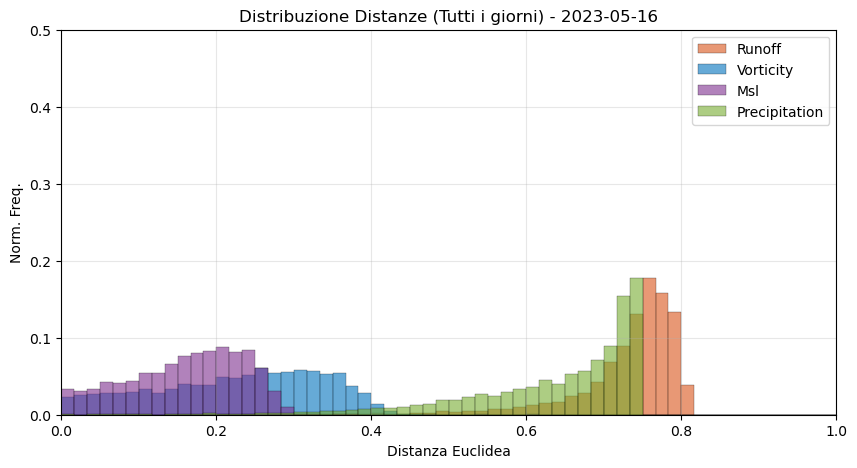


--- Analisi Univariata: runoff ---

========================= TOP 30 ANALOGHI: RUNOFF =========================
Rank  | Periodo FREDDO       | Periodo CALDO       
-------------------------------------------------------
1     | 1974-06-29           | 1997-06-27          
2     | 1973-06-22           | 2013-05-16          
3     | 1972-06-12           | 2002-06-06          
4     | 1978-05-22           | 1988-06-05          
5     | 1965-05-31           | 2017-04-27          
6     | 1951-06-09           | 2010-05-05          
7     | 1984-05-20           | 1999-04-16          
8     | 1975-06-30           | 2002-05-04          
9     | 1984-04-02           | 1986-06-04          
10    | 1981-05-27           | 1995-06-24          
11    | 1982-06-13           | 2011-06-18          
12    | 1953-04-15           | 2017-06-28          
13    | 1978-06-24           | 1995-05-12          
14    | 1965-06-08           | 2010-06-20          
15    | 1963-04-11           | 2013-05-24          

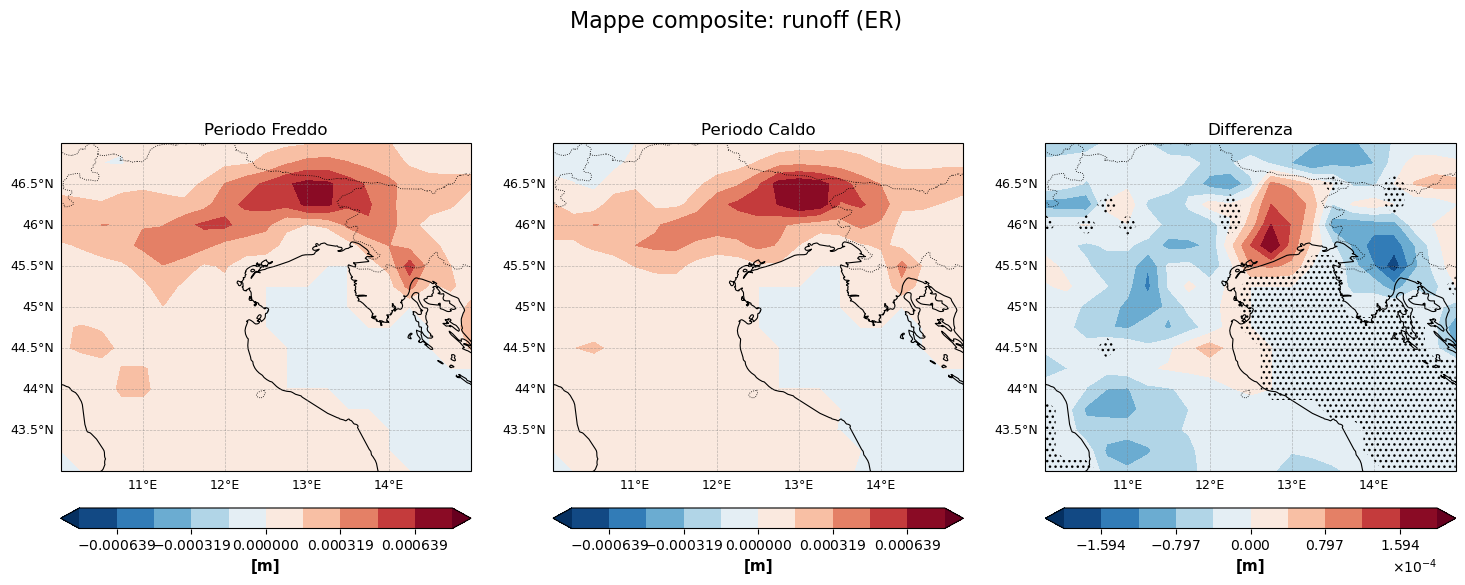

   -> [ANALISI TREND] Generazione Mappe per Segno Trend...
      Counts -> Pos: 1791, Neu: 2871, Neg: 1708


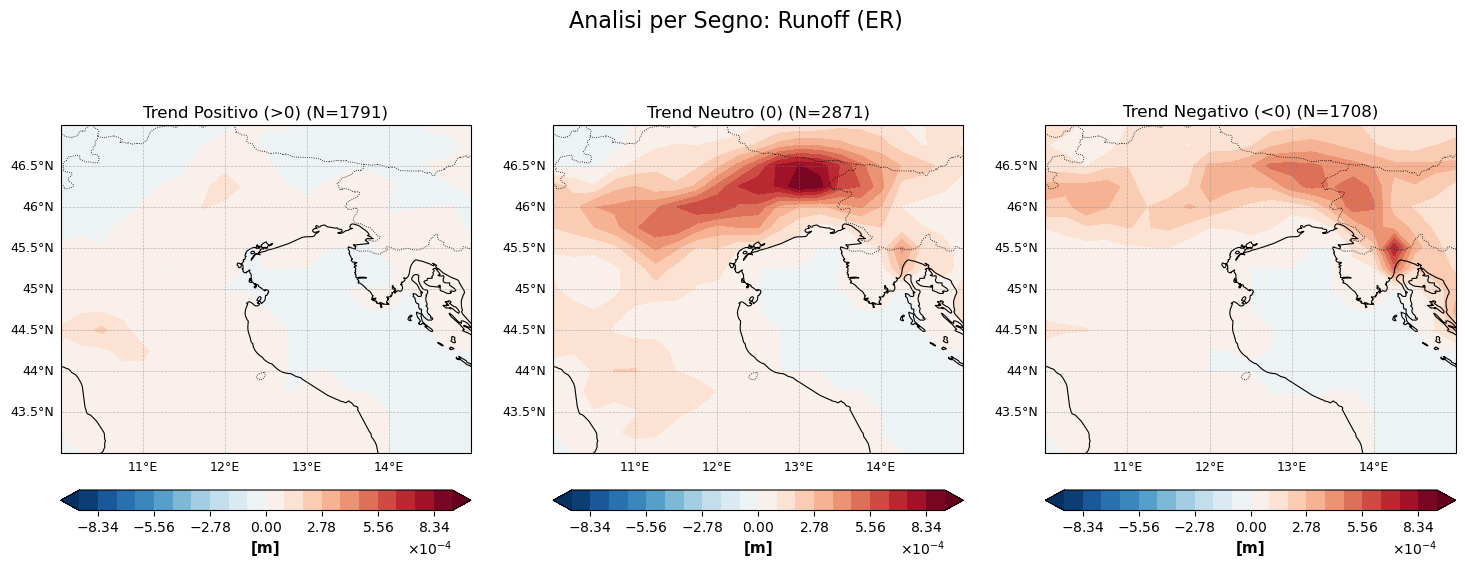


--- Analisi Univariata: vorticity ---

========================= TOP 30 ANALOGHI: VORTICITY =========================
Rank  | Periodo FREDDO       | Periodo CALDO       
-------------------------------------------------------
1     | 1955-04-17           | 1997-04-20          
2     | 1985-04-11           | 2009-04-29          
3     | 1974-05-25           | 2001-04-21          
4     | 1969-04-29           | 2010-06-21          
5     | 1976-05-09           | 2013-06-01          
6     | 1980-05-16           | 2021-05-23          
7     | 1979-06-19           | 1989-04-06          
8     | 1970-04-28           | 1990-04-12          
9     | 1984-04-12           | 2017-04-21          
10    | 1954-04-21           | 2016-04-09          
11    | 1966-05-30           | 2017-05-20          
12    | 1958-05-18           | 1990-04-23          
13    | 1956-05-25           | 2011-06-01          
14    | 1977-04-13           | 2004-04-16          
15    | 1966-05-11           | 1995-04-24    

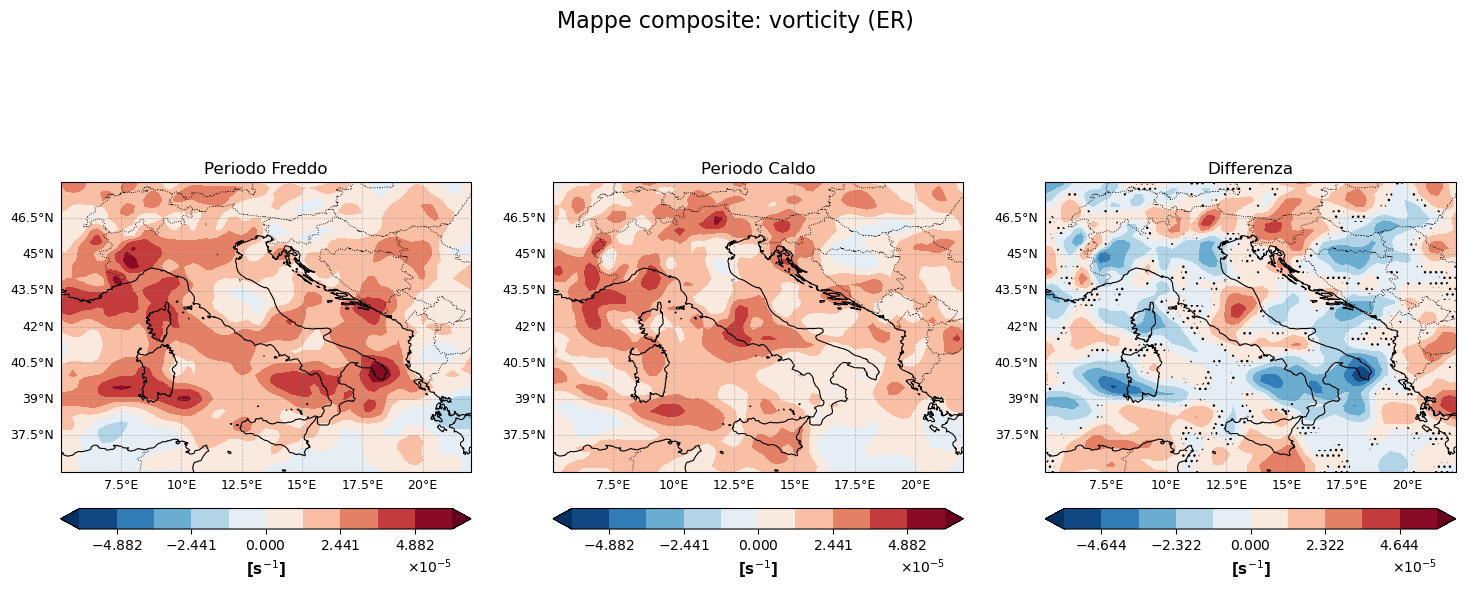

   -> [ANALISI TREND] Generazione Mappe per Segno Trend...
      Counts -> Pos: 18, Neu: 4793, Neg: 1559


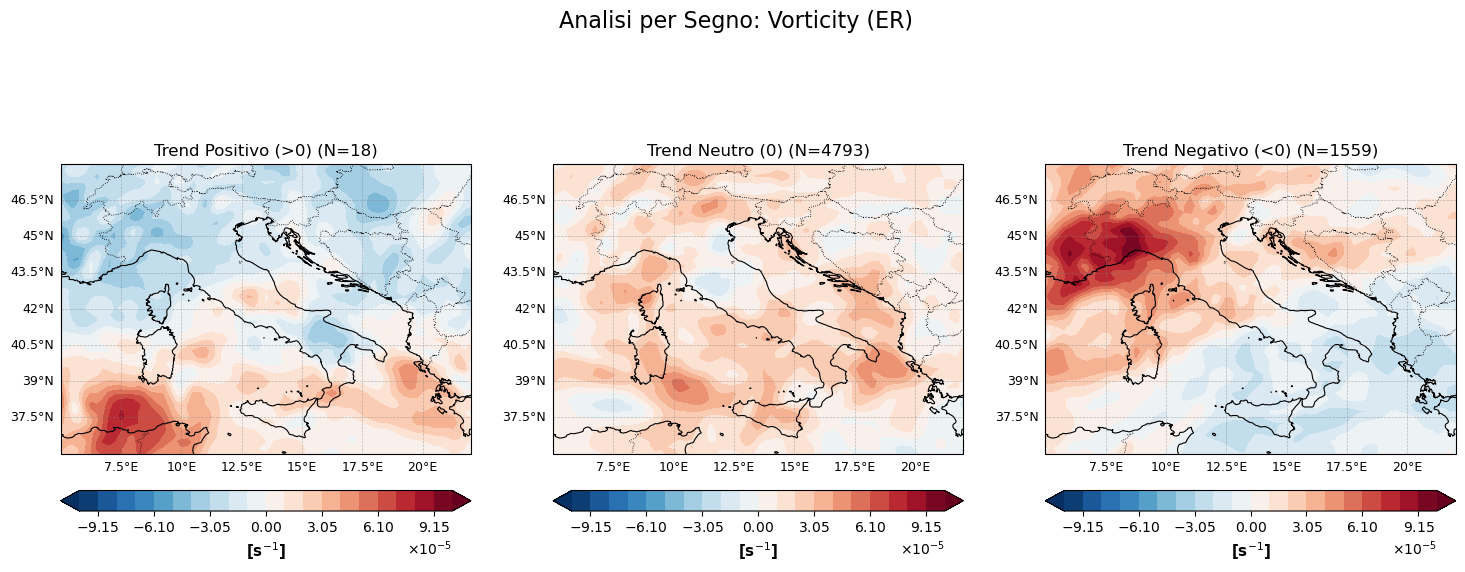


--- Analisi Univariata: msl ---

========================= TOP 30 ANALOGHI: MSL =========================
Rank  | Periodo FREDDO       | Periodo CALDO       
-------------------------------------------------------
1     | 1983-04-16           | 1989-04-26          
2     | 1954-06-08           | 2021-04-12          
3     | 1982-04-15           | 1997-05-08          
4     | 1984-06-04           | 2012-05-12          
5     | 1980-04-22           | 1998-05-02          
6     | 1958-05-16           | 1999-04-07          
7     | 1960-05-03           | 2018-04-07          
8     | 1970-04-23           | 2020-05-23          
9     | 1981-04-21           | 1995-04-03          
10    | 1983-04-05           | 2016-04-02          
11    | 1981-05-04           | 1986-04-22          
12    | 1977-04-12           | 2009-04-13          
13    | 1979-04-25           | 1996-05-01          
14    | 1953-05-02           | 2020-06-05          
15    | 1960-04-08           | 2003-04-30          
16   

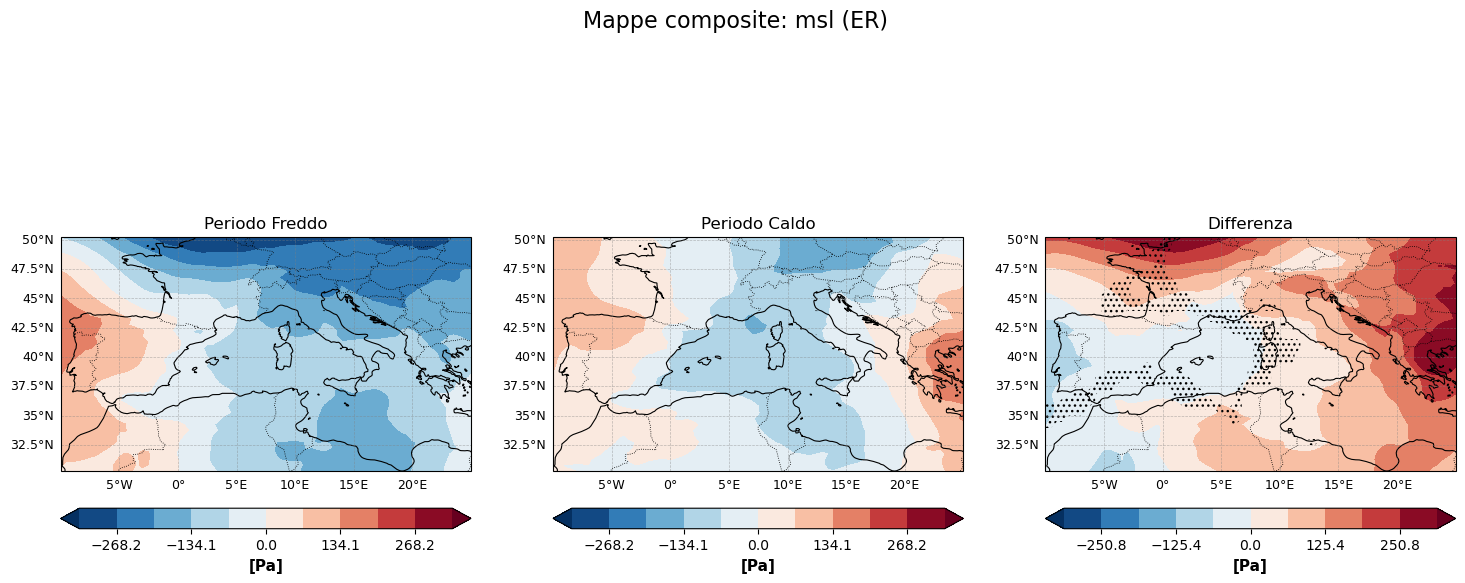

   -> [ANALISI TREND] Generazione Mappe per Segno Trend...
      Counts -> Pos: 149, Neu: 6071, Neg: 150


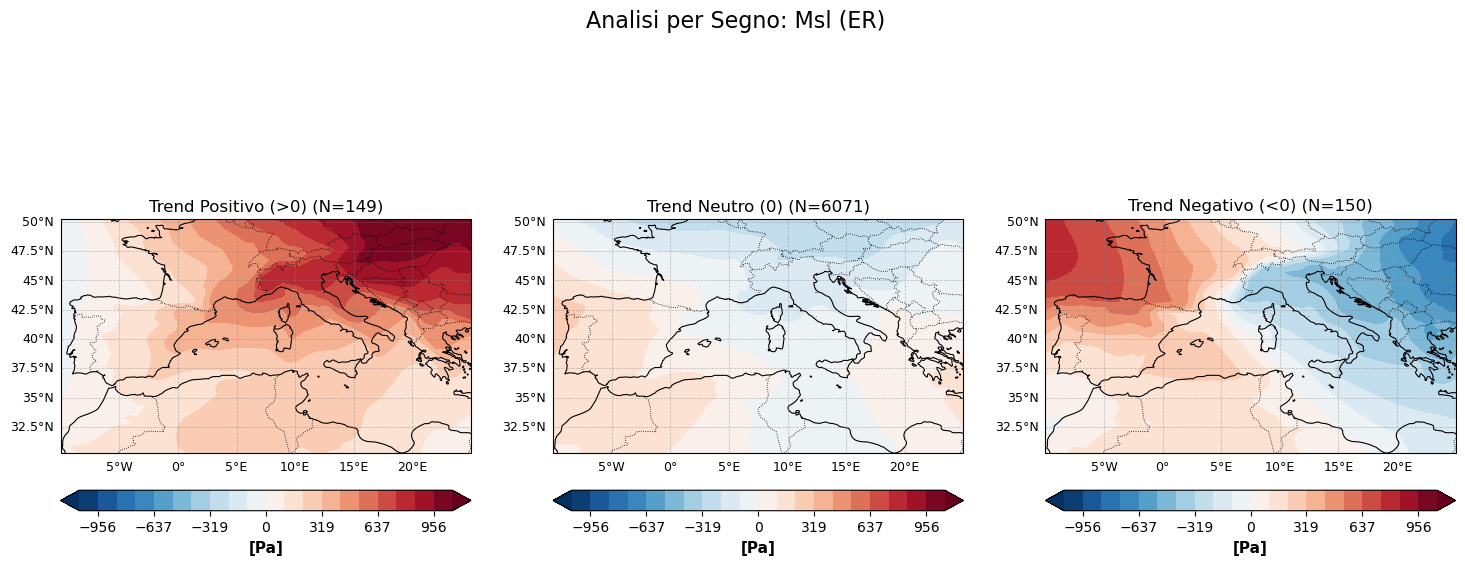


--- Analisi Univariata: precipitation ---

========================= TOP 30 ANALOGHI: PRECIPITATION =========================
Rank  | Periodo FREDDO       | Periodo CALDO       
-------------------------------------------------------
1     | 1973-04-10           | 2020-06-04          
2     | 1975-04-07           | 1997-06-02          
3     | 1967-06-09           | 2002-05-04          
4     | 1972-06-13           | 2017-04-27          
5     | 1967-05-17           | 1995-06-24          
6     | 1977-05-14           | 1996-06-22          
7     | 1962-05-14           | 1992-04-01          
8     | 1963-05-16           | 2005-04-11          
9     | 1979-04-25           | 1994-06-12          
10    | 1981-06-23           | 2002-06-07          
11    | 1967-04-10           | 2017-06-28          
12    | 1989-04-05           | 2021-04-12          
13    | 1978-04-13           | 2019-04-23          
14    | 1966-05-07           | 1997-06-27          
15    | 1984-04-03           | 2009-0

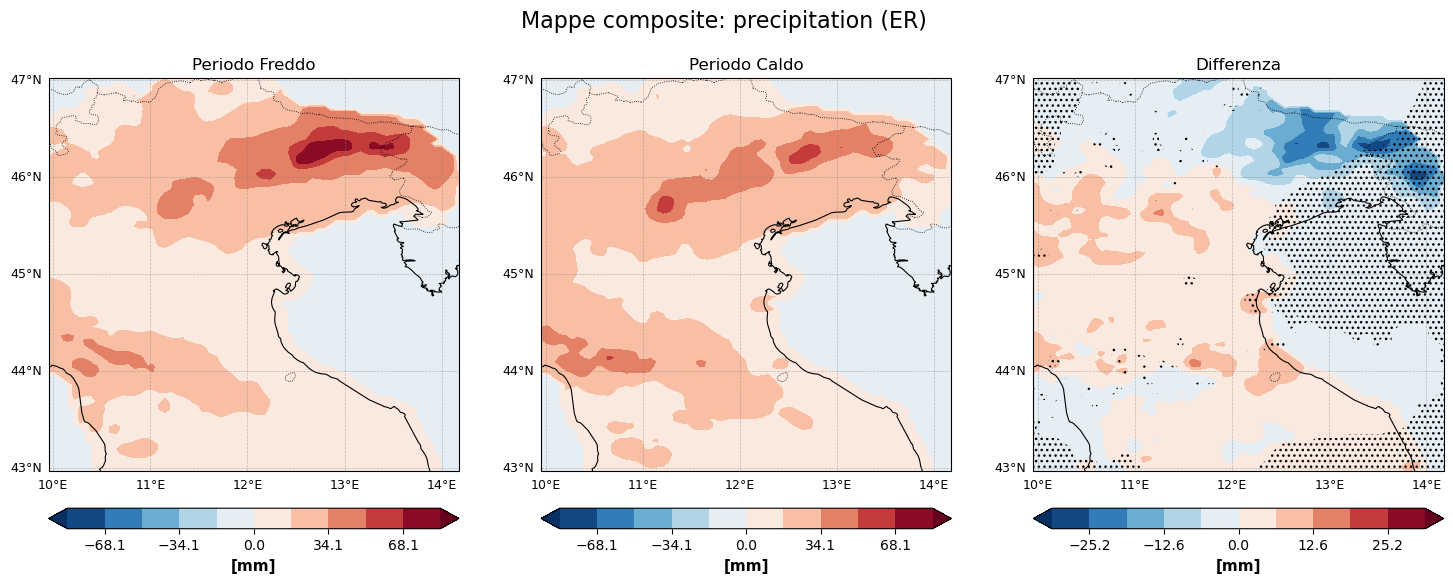

   -> [ANALISI TREND] Generazione Mappe per Segno Trend...
      Counts -> Pos: 3678, Neu: 1782, Neg: 0


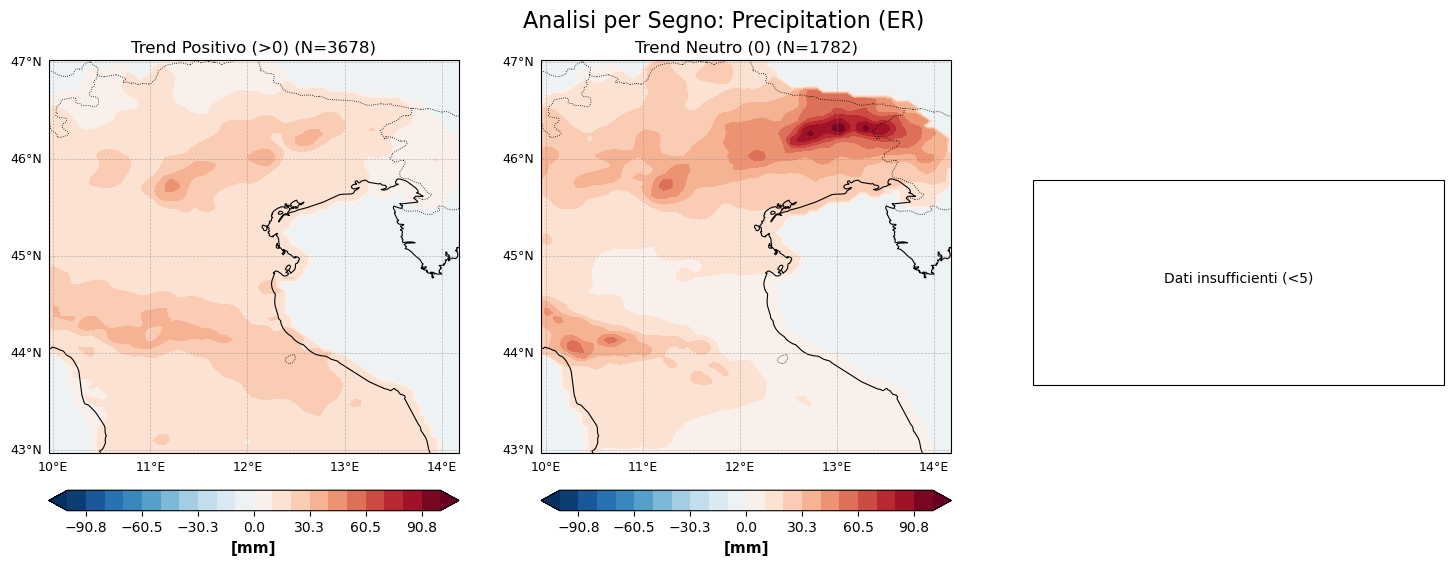


--- Analisi Multivariata: ['runoff', 'msl', 'precipitation'] ---

========================= TOP 30 ANALOGHI: MULTIVARIATA =========================
Rank  | Periodo FREDDO       | Periodo CALDO       
-------------------------------------------------------
1     | 1978-05-22           | 1997-06-27          
2     | 1973-04-10           | 2017-04-27          
3     | 1962-05-14           | 2002-05-04          
4     | 1967-05-17           | 2010-05-05          
5     | 1977-05-14           | 2002-06-06          
6     | 1972-06-12           | 1995-06-24          
7     | 1975-04-06           | 2017-06-28          
8     | 1963-05-16           | 2010-06-20          
9     | 1966-05-07           | 2020-06-04          
10    | 1978-04-13           | 1994-06-12          
11    | 1973-06-22           | 1996-06-22          
12    | 1989-04-05           | 2021-04-12          
13    | 1967-06-09           | 1999-04-16          
14    | 1981-05-27           | 2013-05-16          
15    | 1981-06

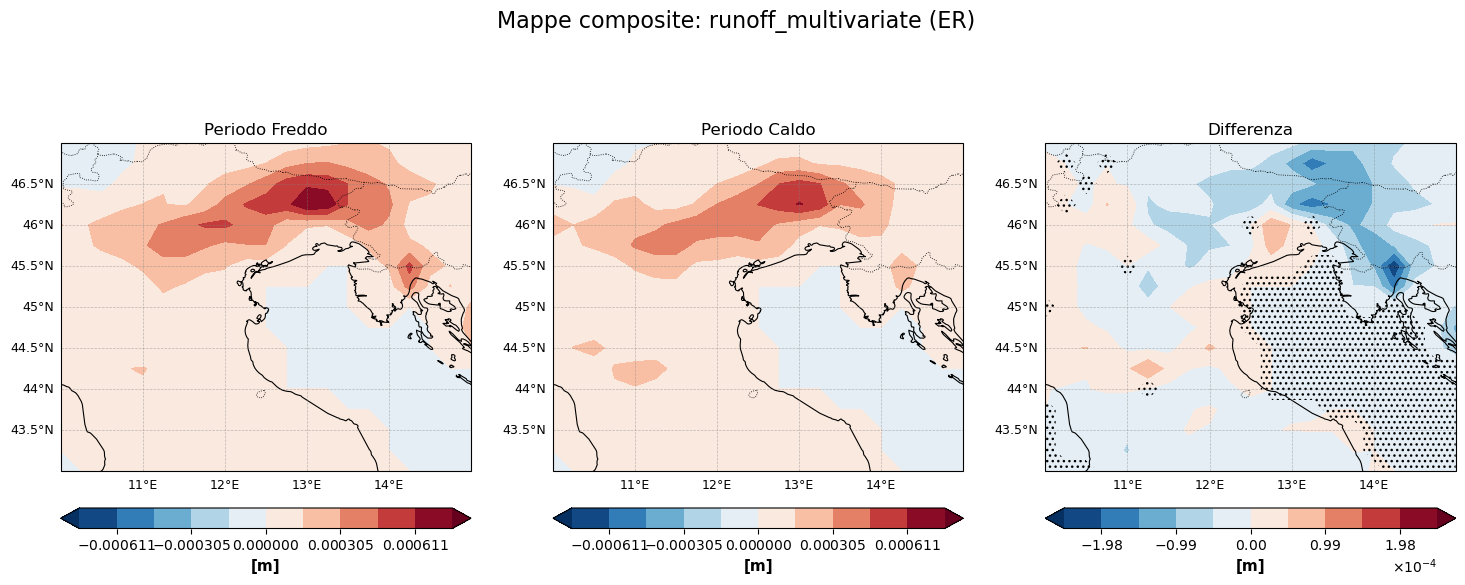

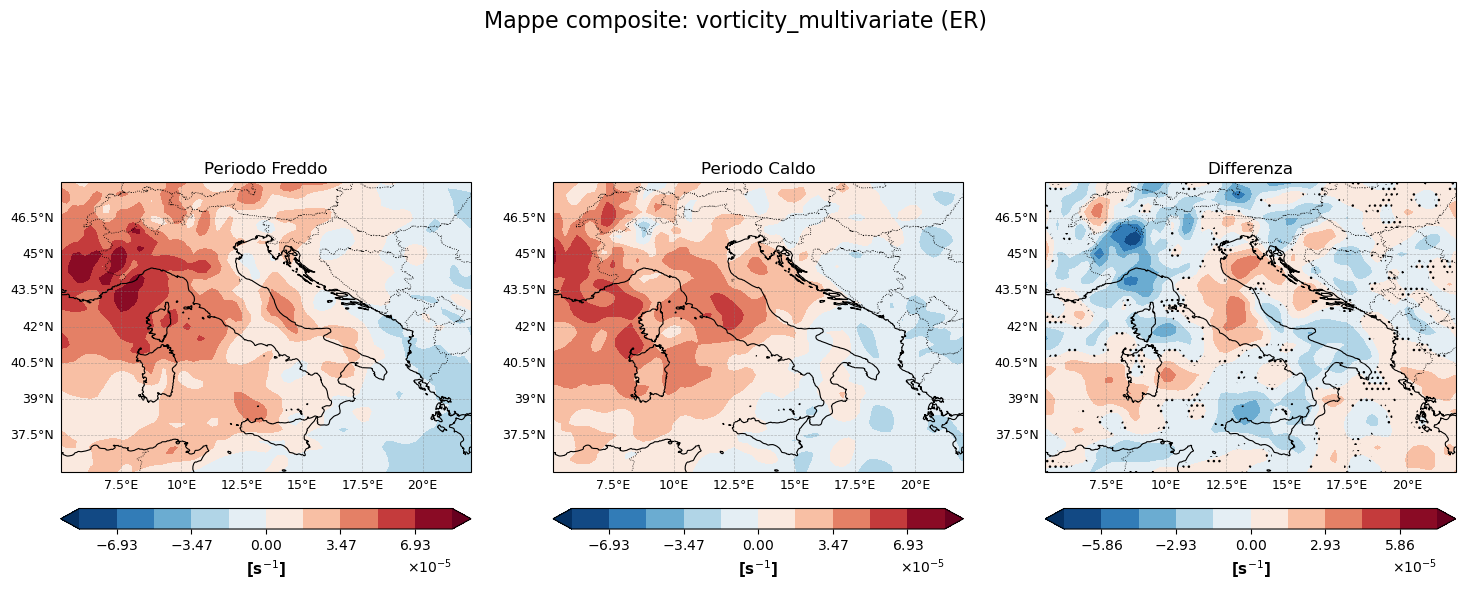

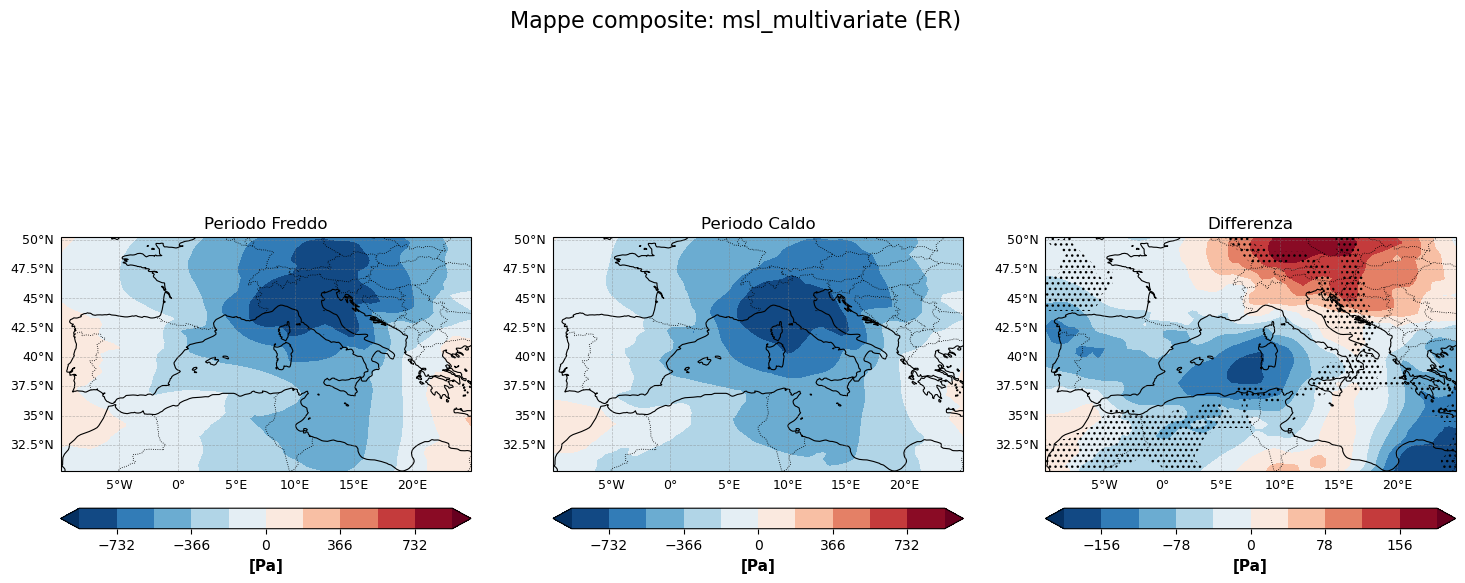

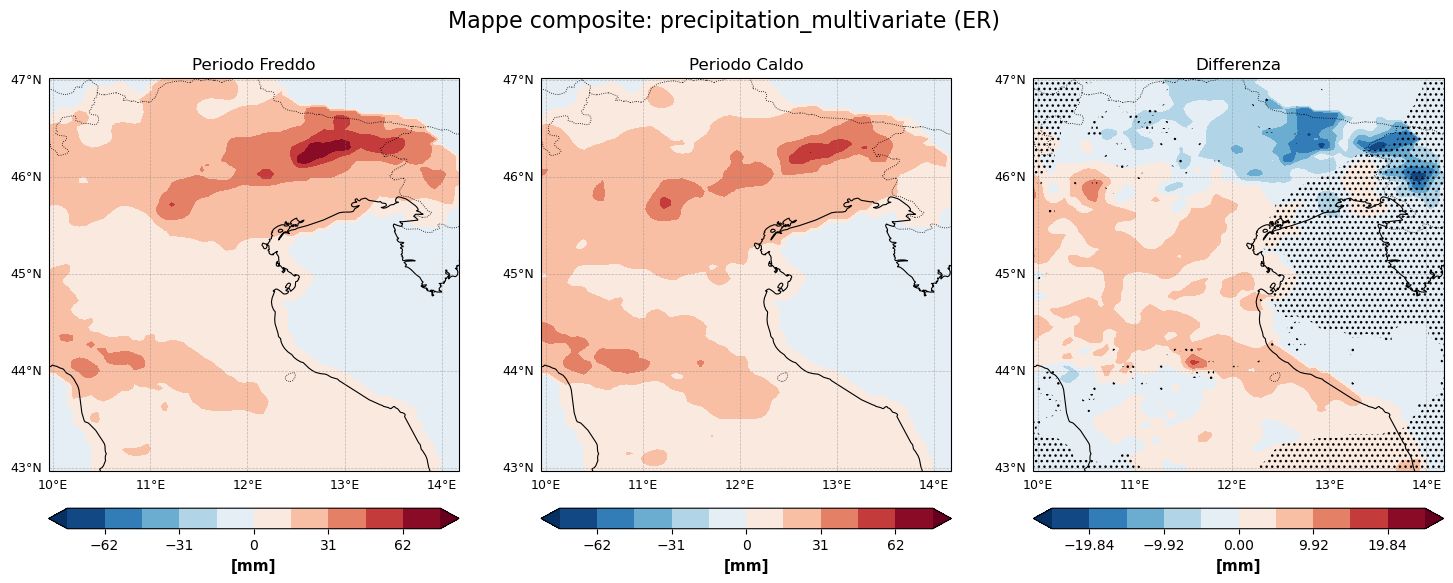


>>> FINE <<<


In [22]:
def main():
    print(f">>> AVVIO ANALISI: {CURRENT_CASE} <<<")
    out_dir = Path(config['PATHS']['OUTPUT'])
    fig_dir = out_dir / "FIG"
    fig_dir.mkdir(parents=True, exist_ok=True)

    # 1. PRECALCOLO
    if ESEGUI_PRECALCOLO:
        for v in config['VARIABLES']: precompute_variable(v, out_dir)

    if not ESEGUI_ANALISI_PLOT: return

    # 2. CARICAMENTO DATI
    data_store = {}
    for v in config['VARIABLES']:
        res = load_precomputed(v['id'], out_dir)
        if res: data_store[v['id']] = res
    if not data_store: print("Nessun dato caricato. Controlla path e suffissi."); return

    # 3. FILTRAGGIO TEMPORALE E CALCOLO DISTANZE
    target_dt = f"{config['DATES']['EVENT_YEAR']}-{config['DATES']['EVENT_DAY']}"
    rel_dists = {}
    print(f"\n>>> Calcolo Distanze vs {target_dt} (Blacklist: {config['BLACKLIST']})")
    
    for vid, content in data_store.items():
        res, dists = calculate_relative_distances(content['da'], content['dist_av'], target_dt, config['BLACKLIST'])
        if res is not None:
            data_store[vid]['da_filtered'] = res
            rel_dists[vid] = dists

    # 4. ISTOGRAMMA GENERALE
    print("\n>>> GENERAZIONE ISTOGRAMMI <<<")
    plot_distance_histogram(rel_dists, out_dir, filename="histogram_distances_ALL.png", title=f'Distribuzione Distanze (Tutti i giorni) - {target_dt}')

    #PER VALENCIA: istogramma con soglia
    if CURRENT_CASE == 'VALENCIA' and 'runoff' in data_store and 'runoff' in rel_dists:
        try:
            ro_da = data_store['runoff']['da_filtered']
            spatial_means = ro_da.mean(dim=['lat', 'lon']).values
            threshold = 0.00001
            is_wet = spatial_means > threshold
            wet_runoff_dists = rel_dists['runoff'][is_wet]
            
            print(f"   Giorni Runoff 'Wet' (> {threshold}): {len(wet_runoff_dists)} su {len(spatial_means)}")
            
            mixed_dists_store = rel_dists.copy()
            mixed_dists_store['runoff'] = wet_runoff_dists
            
            plot_distance_histogram(mixed_dists_store, out_dir, filename="histogram_distances_WET_RUNOFF.png", title=f'Distribuzione Distanze (Runoff Wet Only > {threshold})')
        except Exception as e:
            print(f"Errore generazione istogramma Wet-Runoff: {e}")

    # 5. ANALISI UNIVARIATA
    for vid in data_store:
        if vid not in rel_dists: continue
        print(f"\n--- Analisi Univariata: {vid} ---")
        analogs = select_analogs(data_store[vid]['da_filtered'], rel_dists[vid], NUM_ANALOGS)
        print_analog_dates(analogs, vid.upper())
        sig_mask = None
        
        # Bootstrap Univariata
        if RUN_BOOTSTRAP and vid in ['runoff', 'vorticity','msl', 'precipitation']:
            df = data_store[vid]['da_filtered']
            full_len = len(df)
            dummy_cold_idx = np.arange(full_len // 2)
            dummy_warm_idx = np.arange(full_len - len(dummy_cold_idx))
            current_n_boot = 100 if vid == 'vorticity' else 100
            
            sig_mask = bootstrap_significance(
                None, None, dummy_cold_idx, dummy_warm_idx,
                df[:len(dummy_cold_idx)], df[len(dummy_cold_idx):], 
                analogs['warm']['data'].mean('time') - analogs['cold']['data'].mean('time'), 
                current_n_boot
            )
        
        plot_composite_maps(analogs, vid, fig_dir, sig_mask)

        
        # Trend Analysis
        if 'signt_da' in data_store[vid]:
            signt_da = data_store[vid]['signt_da']
            signt_aligned = signt_da.sel(time=data_store[vid]['da_filtered'].time).values
            analyze_by_trend_sign(data_store[vid]['da_filtered'], rel_dists[vid], signt_aligned, vid, fig_dir)
            
        # Studio del runoff per Valencia
        if CURRENT_CASE == 'VALENCIA' and vid == 'runoff':
            analyze_runoff_magnitudes_valencia(analogs, data_store[vid]['da'], target_dt, out_dir)

    # 6. ANALISI MULTIVARIATA
    print(f"\n--- Analisi Multivariata: {config['MULTI_VARS']} ---")
    available = [v for v in config['MULTI_VARS'] if v in rel_dists]
    if len(available) == len(config['MULTI_VARS']):
        dist_das = [xr.DataArray(rel_dists[v], coords={'time': data_store[v]['da_filtered'].time}, dims='time') for v in available]
        ds_merged = xr.merge([d.rename(available[i]) for i, d in enumerate(dist_das)], join='inner')
        combined_dist = ds_merged.to_array().sum('variable')
        base_aligned = data_store[available[0]]['da_filtered'].sel(time=combined_dist.time)
        analogs_multi = select_analogs(base_aligned, combined_dist.values, NUM_ANALOGS)
        print_analog_dates(analogs_multi, "MULTIVARIATA")
        
        for tgt in data_store:
            if 'da_filtered' not in data_store[tgt]: continue
            try:
                tgt_da = data_store[tgt]['da_filtered'].sel(time=combined_dist.time)
                mid = len(tgt_da)//2
                an_tgt = {'cold': {'data': tgt_da[:mid].isel(time=analogs_multi['cold']['indices'])},
                          'warm': {'data': tgt_da[mid:].isel(time=analogs_multi['warm']['indices'])}}
                
                # Bootstrap Multivariata
                sig_mask_multi = None
                if RUN_BOOTSTRAP and tgt in ['runoff', 'vorticity', 'msl', 'precipitation']:
                    full_len_m = len(tgt_da)
                    dummy_cold_idx_m = np.arange(full_len_m // 2)
                    dummy_warm_idx_m = np.arange(full_len_m - len(dummy_cold_idx_m))
                    current_n_boot = 100 if tgt == 'vorticity' else 100
                    
                    sig_mask_multi = bootstrap_significance(
                        None, None, dummy_cold_idx_m, dummy_warm_idx_m,
                        tgt_da[:len(dummy_cold_idx_m)], tgt_da[len(dummy_cold_idx_m):], 
                        an_tgt['warm']['data'].mean('time') - an_tgt['cold']['data'].mean('time'), 
                        current_n_boot
                    )
                
                plot_composite_maps(an_tgt, f"{tgt}_multivariate", fig_dir, sig_mask_multi)
            except: pass

    # 7. ANALISI PROXY (CON BOOTSTRAP)
    if ESEGUI_ANALISI_PROXY:
        print("\n--- Analisi Proxy ---")
        for pxy in config['PROXY_VARS']:
            if pxy not in rel_dists: continue
            print(f"Driver: {pxy}")
            d_pxy = xr.DataArray(rel_dists[pxy], coords={'time': data_store[pxy]['da_filtered'].time}, dims='time')
            
            for tgt in data_store:
                if tgt == pxy or 'da_filtered' not in data_store[tgt]: continue
                try:
                    d_aligned = d_pxy.reindex(time=data_store[tgt]['da_filtered'].time, method='nearest', tolerance='1D')
                    valid = ~np.isnan(d_aligned.values)
                    
                    if np.sum(valid) > NUM_ANALOGS*2:
                        # Dataset filtrato su cui calcoliamo gli analoghi
                        tgt_da_proxy = data_store[tgt]['da_filtered'].isel(time=valid)
                        
                        an_pxy = select_analogs(tgt_da_proxy, d_aligned.values[valid], NUM_ANALOGS)
                        
                        
                        sig_mask_proxy = None
                        if RUN_BOOTSTRAP and tgt in ['runoff', 'vorticity','msl','precipitation']:
                            full_len_p = len(tgt_da_proxy)
                            dummy_cold_idx_p = np.arange(full_len_p // 2)
                            dummy_warm_idx_p = np.arange(full_len_p - len(dummy_cold_idx_p))
                            current_n_boot = 100 if tgt == 'vorticity' else 100
                            
                            sig_mask_proxy = bootstrap_significance(
                                None, None, dummy_cold_idx_p, dummy_warm_idx_p,
                                tgt_da_proxy[:len(dummy_cold_idx_p)], tgt_da_proxy[len(dummy_cold_idx_p):], 
                                an_pxy['warm']['data'].mean('time') - an_pxy['cold']['data'].mean('time'), 
                                current_n_boot
                            )
                        

                        plot_composite_maps(an_pxy, f"{tgt}_proxy_{pxy}", fig_dir, sig_mask_proxy)
                except: pass

    print("\n>>> FINE <<<")

# Esecuzione
if __name__ == "__main__":
    main()